In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add dirctory with model moduels to path
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds

# Create input data
x0_crp.csv and x0_ani.csv represent the current areas of different crops and number of heads of different animals respectively. These are both still WIP, which is why some mangling is needed here to get them in the right form.
The demand vector is generated with demand for cattle meat, pig meat and cattle milk equal to what is in the agricultural statistics.

In [2]:
# Define x0_crp
x0_crp = \
    pd.read_csv(os.path.join('..','data','x0','x0_crp.csv'), dtype={'region': object})\
    .set_index(['crop','prod_system','region'])['area']

# Define x0_ani
x0_ani = pd.read_csv(os.path.join('..','data','x0','x0_ani.csv'), dtype={'region': object})

x0_ani['species'] = np.nan
x0_ani['species'] = \
np.where(np.isin(x0_ani['animal'], ['kor för mjölkproduktion', 'kor för uppfödning av kalvar']),'cattle',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='suggor för avel','pigs',x0_ani['species'])

x0_ani['breed'] = np.nan
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för mjölkproduktion','dairy',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för uppfödning av kalvar','beef',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='suggor för avel','none',x0_ani['breed'])

x0_ani = x0_ani[x0_ani['species']!='nan'][['species','breed','prod_system','region','number']].set_index(['species','breed','prod_system','region'])['number']

x0_ani = x0_ani.fillna(0)

x0 = {'ani':x0_ani,'crp':x0_crp}

In [3]:
# Create demand vectors
D=dict()

In [4]:
# Animal products
D['ani'] = pd.Series(
    {
        ('conventional','cattle','meat') : (136-21) * 1000000,
        ('organic','cattle','meat')      : 21 * 1000000,
        ('conventional','cattle','milk') : (2760-464) * 1000000,
        ('organic','cattle','milk')      : 464 * 1000000,
        ('conventional','pigs','meat')   : (249-6) * 1000000,
        ('organic','pigs','meat')        : 6 * 1000000,
    },
)
D['ani'].index.rename(['prod_system','species','animal_prod'], inplace=True)

In [5]:
# Crop products (kg DM)
D['crp'] = pd.Series(
    {
        ('conventional','wheat')         :0,
        ('organic','wheat')              :0,
    },
)
D['crp'].index.rename(['prod_system','crop_prod'], inplace=True)

## Work on Diet class

In [6]:
# Instantiate diet class
diet = cm.Diet(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','Diet.xlsx')
    )
)

In [7]:
# Calculate food demand
diet.calculate(verbose=True)

[15:14:40][Diet] Calculating food demand ...
[15:14:40][Diet] Calculating waste ...
[15:14:40][Diet] Calculating crop product demand ...
[15:14:40][Diet] Calculating crop product demand ...
[15:14:41][Diet] Done! Elapsed time: 0 sec


In [8]:
##################################################
##################################################

In [9]:
round(diet.crop_prod_demand/1000000,1) # 1000 ton

prod_system   crop_prod
conventional  wheat        501.7
              barley        20.2
              rye           74.1
              oats          47.2
organic       wheat         28.1
              barley         1.0
              rye           10.8
              oats           8.8
dtype: float64

In [10]:
round(diet.crop_by_products/1000000,1) # 1000 ton

prod_system   crop_prod  by_prod
conventional  barley     bran        0.0
                         hulls       1.7
              oats       offals     11.8
              rye        bran       11.8
              wheat      bran       75.3
                         germ        7.9
organic       barley     bran        0.0
                         hulls       0.1
              oats       offals      2.2
              rye        bran        1.7
              wheat      bran        4.2
                         germ        0.4
dtype: float64

In [11]:
round(diet.animal_prod_demand/1000000,1) # 1000 ton

prod_system   species  animal_prod
conventional  cattle   meat             79.9
                       milk           2174.1
              pigs     meat            242.2
organic       cattle   meat             14.6
                       milk            445.3
              pigs     meat              6.0
dtype: float64

In [12]:
round(diet.animal_by_products/1000000,1) # 1000 ton

prod_system   species  animal_prod  by_prod           
conventional  cattle   milk         buttermilk            15.8
                       meat         butcher fat            6.8
                                    offals                 7.6
                                    skins                  6.5
                                    slaughterhouse fat     3.3
                       milk         whey                  56.4
              pigs     meat         butcher fat           31.8
                                    offals                 9.3
                                    skins                 11.6
                                    slaughterhouse fat    14.0
organic       cattle   milk         buttermilk             3.2
                       meat         butcher fat            1.2
                                    offals                 1.4
                                    skins                  1.2
                                    slaughterhouse fat     0.6


In [13]:
round(diet.induced_skim_milk_exports/1000000,1)*0.1 # 1000 ton powder

prod_system
conventional    50.70
organic         10.39
dtype: float64

In [14]:
D['crp'] = diet.crop_prod_demand

In [15]:
D['ani'] = diet.animal_prod_demand

In [ ]:
######################################################
######################################################

# Run base year
This runs the model for the base year (2016-2020). Results are then compared to statistics to ensure feasible results replicating the current situation.

In [38]:
# Instantiate crop production
crops = cm.CropProduction(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','CropProduction.xlsx')
    ),
    index = x0_crp.index
)    

# Instantiate animal herds
herds=pd.Series(
    data=[],
    index=pd.MultiIndex(
        levels=[[]]*4,
        codes=[[]]*4,
        names=['species','breed','prod_system','sub_system']
    ),
    dtype = object
)

for (sp,br,ps) in x0_ani.groupby(['species','breed','prod_system']).sum().index:
            
    if sp == 'cattle':
        herds[(sp,br,ps,'none')] = \
            cm.CattleHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','CattleHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )

    elif sp == 'pigs':
        herds[(sp,br,ps,'none')] = \
            cm.PigHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','PigHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            ) 

# Instantiate manure management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','FeedMgmt.xlsx')
    )
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','ManureMgmt.xlsx')
    )
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(D,x0,crops,herds,feed_mgmt)

# -------------------------------------------------------------------- #

# Calculate crops
crops.calculate(
    verbose = True
)

# Calculate herds
for h in herds:
    h.calculate(verbose = True)

# Calculate feed
feed_mgmt.calculate(verbose=True)    

# Calculate manure
manure_mgmt.calculate(verbose=True)

[15:25:32][CropProduction] Calculating harvest ...
[15:25:32][CropProduction] Calculating production ...
[15:25:32][CropProduction] Done! Elapsed time: 0 sec
[15:25:32][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[15:25:32][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[15:25:32][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[15:25:32][AnimalHerd (cattle, beef, organic, none)] Calculating herd structure ...
[15:25:33][AnimalHerd (cattle, beef, organic, none)] Calculating production ...
[15:25:33][AnimalHerd (cattle, beef, organic, none)] Done! Elapsed time: 1 sec
[15:25:33][AnimalHerd (cattle, dairy, conventional, none)] Calculating herd structure ...
[15:25:33][AnimalHerd (cattle, dairy, conventional, none)] Calculating production ...
[15:25:34][AnimalHerd (cattle, dairy, conventional, none)] Done! Elapsed time: 0 sec
[15:25:34][AnimalHerd (cattle, dairy, organic, none)] Calculating herd structure

In [39]:
# Distribute animals and crops
geodist.make(use_cons=[1,2,3,4],verbose=True)

[15:25:55][GeoDist.make] Making constraint C1 ...
[15:25:58][GeoDist.make] Making constraint C2 ...
[15:26:58][GeoDist.make] Making constraint C3 ...
[15:26:58][GeoDist.make] Making constraint C4 ...
[15:26:58][GeoDist.make] Making objective O1 ...
[15:26:59][GeoDist.make] Defining problem ...
[15:26:59][GeoDist.make] Done! Elapsed time: 63 sec


In [48]:
geodist.solve(
    verbose=True,
    solver_settings = {
        'solver':'OSQP',
        'max_iter':50000,
        'eps_abs':1e-5,
        'eps_rel':1e-5,
        'verbose':True
    }
)

[15:29:08][GeoDist.solve] Finding solution ...
                                     CVXPY                                     
                                     v1.3.0                                    
(CVXPY) Apr 28 03:29:08 PM: Your problem has 12084 variables, 4 constraints, and 0 parameters.
(CVXPY) Apr 28 03:29:08 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 28 03:29:08 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 28 03:29:08 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Apr 28 03:29:08 PM: Using cached ASA map, for faster compilation (bypassing reduction chain).
(CVXPY) Apr 

In [49]:
# Scale and store results
out_crops = crops.scale(geodist.x['crp'])

out_animals = concat_herds([
    h.scale(
        geodist.x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
        x_is = h.x_is
    )
    for h in herds
])

# Check solution

### Check constraint C<sub>1</sub>

Production meets demand

In [50]:
# Check constraint C1 (production meets demand)
round(pd.Series(
    geodist.A1.M @ np.concatenate((geodist.x['ani'].values,geodist.x['crp'].values)) -
    np.concatenate([geodist.D['ani'],geodist.D['crp']]),
    index=np.concatenate((geodist.A1.rows['ani'].values,geodist.A1.rows['crp'].values))
)/1000,2)

(conventional, cattle, meat)    0.0
(conventional, cattle, milk)    0.0
(conventional, pigs, meat)      0.0
(organic, cattle, meat)         0.0
(organic, cattle, milk)         0.0
(organic, pigs, meat)           0.0
(conventional, wheat)          -0.0
(conventional, barley)          0.0
(conventional, rye)             0.0
(conventional, oats)            0.0
(organic, wheat)               -0.0
(organic, barley)               0.0
(organic, rye)                  0.0
(organic, oats)                 0.0
(conventional, fodder)         -0.0
(organic, fodder)              -0.0
(conventional, maize fodder)    0.0
(organic, maize fodder)         0.0
(conventional, grazing)        -0.0
(organic, grazing)             -0.0
dtype: float64

Also check that this demand is met when looking at the output tables.

Prod - Diet - Feed = 0

In [51]:
# Check if crop production meets demand
tmp = pd.concat([
    # Crop production
    out_crops.production.rename_axis(columns='crop_prod').stack().groupby(['prod_system','crop_prod']).sum().rename('prod'),
    # Diet demand
    -geodist.D['crp'].rename('diet'),
    # Feed demand
    -out_animals.feed.crop_product_demand
    .xs('domestic',level='origin',axis=1)
    .groupby(['prod_system','crop_prod'],axis=1)
    .sum().sum()
    .rename('feed')
], axis=1)
tmp['sum'] = tmp.sum(axis=1)
round(tmp/1000,1)


prod      diet       feed  sum
prod_system  crop_prod                                        
conventional maize fodder        0.0      -0.0        NaN  0.0
             fodder        1283236.1      -0.0 -1283236.1 -0.0
             grazing        408172.9      -0.0  -408172.9 -0.0
             wheat         2053336.0 -501666.2 -1551669.8 -0.0
             barley          20236.1  -20236.1        NaN  0.0
             rye             74057.6  -74057.6        NaN  0.0
             oats            47188.7  -47188.7        NaN  0.0
organic      maize fodder        0.0      -0.0        NaN  0.0
             fodder         298096.5      -0.0  -298096.5 -0.0
             grazing        110380.1      -0.0  -110380.1 -0.0
             wheat          205864.9  -28076.4  -177788.5 -0.0
             barley           1042.7   -1042.7        NaN  0.0
             rye             10773.6  -10773.6        NaN  0.0
             oats             8788.4   -8788.4        NaN  0.0

In [52]:
# Check if animal production meets demand

tmp = pd.concat([
    # Animal production
    out_animals.production.groupby(['prod_system','species','animal_prod'],axis=1).sum().sum().rename('prod'),
    # Diet demand
    -geodist.D['ani'].rename('diet'),
],axis=1)
tmp['sum'] = tmp.sum(axis=1)
round(tmp/1000,1)

prod       diet  sum
prod_system  species animal_prod                           
conventional cattle  meat           79939.4   -79939.4  0.0
                     milk         2174142.2 -2174142.2  0.0
             pigs    meat          242188.1  -242188.1  0.0
organic      cattle  meat           14551.6   -14551.6  0.0
                     milk          445306.2  -445306.2  0.0
             pigs    meat            5955.4    -5955.4  0.0

### Check deviations from x0

In [53]:
print('Crops max(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).max())
print('Crops min(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).min())
print('Animals max(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).max())
print('Animals min(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).min())

Crops max(x-x0) [ha]: 544.5237127879741
Crops min(x-x0) [ha]: -8908.421708975571
Animals max(x-x0) [nr]: 500.1685223670786
Animals min(x-x0) [nr]: -1991.1276574583596


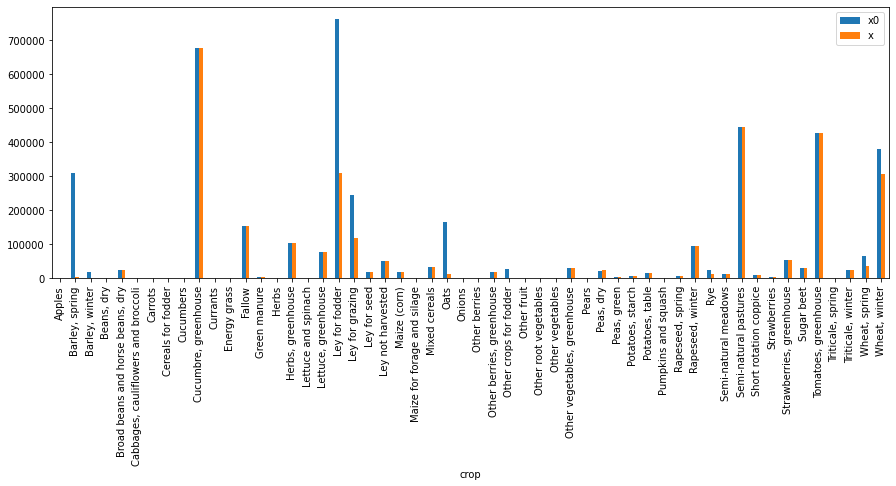

In [54]:
fig, ax = plt.subplots(figsize=(15,5))

pd.concat([
    x0_crp.groupby('crop').sum().rename('x0'),
    out_crops.area.groupby('crop').sum().rename('x')
], axis=1).plot.bar(ax=ax)

plt.show()

In [55]:
idx = pd.IndexSlice

print(
    pd.concat([
        out_animals.heads
        .groupby(['species','breed','prod_system','animal'], axis=1).sum()
        .sum().loc[idx[:,:,:,['cows','sows']]].droplevel('animal')
        .rename('x')
        ,
        x0_ani
        .groupby(['species','breed','prod_system']).sum()
        .rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

print(
    pd.concat([
        out_crops.area.groupby('crop').sum().rename('x'),
        x0_crp.groupby('crop').sum().rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

                                   x        x0  % dif
species breed prod_system                            
cattle  beef  conventional   51264.7  128080.1  -60.0
              organic        31752.5   72274.4  -56.1
        dairy conventional  233433.0  263227.4  -11.3
              organic        52369.2   54920.6   -4.6
pigs    none  conventional  101409.5  132262.5  -23.3
              organic         3426.8    3325.0    3.1
                                            x        x0  % dif
crop                                                          
Apples                                 1728.2    1552.0   11.4
Barley, spring                         4847.3  309454.0  -98.4
Barley, winter                            0.1   18623.4 -100.0
Beans, dry                              885.7     703.3   25.9
Broad beans and horse beans, dry      25872.3   25705.0    0.7
Cabbages, cauliflowers and broccoli    1635.0    1468.5   11.3
Carrots                                1927.5    1760.5    9.5
C

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_1572\3424063546.py:32: RuntimeWarning: divide by zero encountered in double_scalars
  [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
C:\Users\jnka0003\AppData\Local\Temp\ipykernel_1572\3424063546.py:32: RuntimeWarning: divide by zero encountered in double_scalars
  [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
